# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

**Loading the dataset**

In [1]:
import duckdb
con = duckdb.connect()
con.execute("CREATE SECRET (TYPE huggingface, TOKEN '')")  # accept the gate in-browser first, then paste a READ token
rel = "hf://datasets/FlyRank/internship-warehouse"
con.sql(f"SELECT COUNT(*) FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet')")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     78835655 │
└──────────────┘

In [2]:
table = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet"

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

**Two things stand out, and the second matters more than the first for everything below.**

Every count field is heavily right-skewed, as expected: `impressions_feb` skew = 19.4,
`clicks_feb` skew = 67.1 — the mean (586 impressions) is nowhere near the median (0). That's
the heavy tail: a small number of high-traffic pages carry most of the volume, visible clearly
in the log-scale histogram's huge spike at 0 with a long thinning tail out past 10.

**But the real finding is missingness, not skew.** Only 145,279 of 303,572 pages (48%) have
any `avg_position_feb` at all — the rest had zero impressions in February, so position and CTR
are undefined for over half the panel. Worse: `engagement_rate_feb` and `scroll_rate_feb` are
only usable for ~33,300 pages each — **11% of the panel**. Any rule or model built on GA4
engagement signals is implicitly only usable on a ninth of the data unless that gap is handled
explicitly, not silently dropped.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

       impressions_feb  clicks_feb  avg_position_feb     ctr_feb  \
count       303572.000  303572.000        145279.000  145279.000   
mean           585.929       1.916            12.295       0.005   
std           2918.189      15.688            13.703       0.041   
min              0.000       0.000             0.000       0.000   
50%              0.000       0.000             7.722       0.000   
75%            105.000       0.000            14.036       0.002   
90%           1143.000       2.000            27.831       0.006   
95%           2788.000       8.000            40.922       0.011   
99%          10569.290      37.000            68.280       0.077   
max         203401.000    3310.000           633.000       1.000   

       engagement_rate_feb  scroll_rate_feb  
count            33347.000        33365.000  
mean                 0.039            0.169  
std                  0.130            0.301  
min                  0.000            0.000  
50%                  

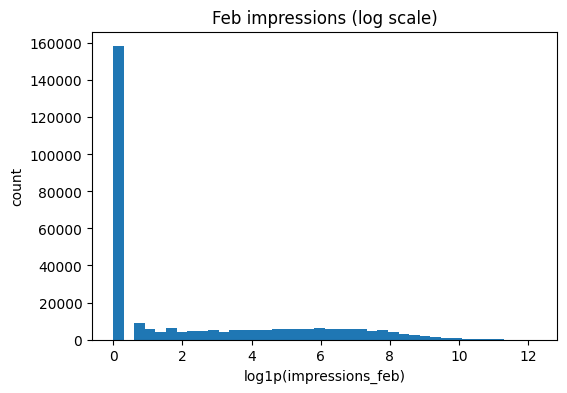

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import numpy as np, pandas as pd, matplotlib.pyplot as plt

PRIOR_MONTH, RECENT_MONTH = "2026-02", "2026-03"

panel = con.sql(f"""
    WITH feb AS (
        SELECT content_hash_id,
               AVG(gsc_avg_position)      AS avg_position_feb,
               SUM(gsc_impressions)       AS impressions_feb,
               SUM(gsc_clicks)            AS clicks_feb,
               SUM(ga4_sessions)          AS ga4_sessions_feb,
               SUM(ga4_engaged_sessions)  AS ga4_engaged_sessions_feb,
               SUM(ga4_pageviews)         AS ga4_pageviews_feb,
               SUM(scroll_events)         AS scroll_events_feb
        FROM read_parquet('{table}') WHERE month = '{PRIOR_MONTH}'
        GROUP BY content_hash_id
    ), mar AS (
        SELECT content_hash_id, SUM(gsc_clicks) AS clicks_mar
        FROM read_parquet('{table}') WHERE month = '{RECENT_MONTH}'
        GROUP BY content_hash_id
    )
    SELECT feb.*, mar.clicks_mar FROM feb JOIN mar USING (content_hash_id)
""").df()

panel["ctr_feb"] = np.where(panel["impressions_feb"] > 0, panel["clicks_feb"] / panel["impressions_feb"], np.nan)
panel["engagement_rate_feb"] = np.where(panel["ga4_sessions_feb"] > 0, panel["ga4_engaged_sessions_feb"] / panel["ga4_sessions_feb"], np.nan)
panel["scroll_rate_feb"] = np.where(panel["ga4_pageviews_feb"] > 0, panel["scroll_events_feb"] / panel["ga4_pageviews_feb"], np.nan)
panel["is_declining"] = (panel["clicks_mar"] < panel["clicks_feb"]).astype(int)

key_fields = ["impressions_feb", "clicks_feb", "avg_position_feb", "ctr_feb", "engagement_rate_feb", "scroll_rate_feb"]
print(panel[key_fields].describe(percentiles=[.5, .75, .9, .95, .99]).round(3))
print("\nSkewness (heavy tail signal -- notably right-skewed above ~1):")
print(panel[key_fields].skew().round(2))

plt.figure(figsize=(6, 4))
plt.hist(np.log1p(panel["impressions_feb"]), bins=40)
plt.xlabel("log1p(impressions_feb)"); plt.ylabel("count"); plt.title("Feb impressions (log scale)")
plt.show()


## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

**Signal #1 — Volume vs. decline rate: MIXED (confounded by the label's zero floor).**
Decline rate climbs sharply with volume (0.000 → 0.000 → 0.047 → 0.280), which looks like
"high-volume pages decline more" — the opposite of the hypothesis. But `is_declining` is
defined as `clicks_mar < clicks_feb`, and the median `clicks_feb` across the whole panel is 0.
A page with zero clicks in February **cannot** register as declining — there's nothing to fall
below zero. q1 and q2 (the bottom half, mostly zero-click pages) are mechanically locked at
0.000, not genuinely "protected from decline." This isn't a real signal yet — it's a label
design flaw. The fix: re-test this signal restricted to pages with `clicks_feb > 0`, where a
decline is actually possible, before trusting the direction either way.

**Signal #2 — Engagement rate vs. decline rate: MIXED.** q1→q2→q3 falls as predicted
(0.224 → 0.155 → 0.141), but q4 jumps to 0.320 — higher than q1. Not monotonic, so it doesn't
cleanly confirm or refute. Worth checking whether q4 is dominated by very-low-session pages
(e.g. 1 engaged session out of 1 total session = engagement_rate of 1.0), which would make the
top quartile mostly noise from tiny denominators rather than a real "highly engaged" group.

**Signal #3 — Scroll rate vs. decline rate: FALSE.** q1, q2, and q4 are essentially identical
(0.172 / 0.171 / 0.171) — flat, no relationship. q3's spike to 0.326 looks like noise sitting
in the middle of an otherwise flat line, not a real pattern. Scroll rate does not predict
decline here, and that's a clean, useful negative: it can be dropped from any future rule
without losing anything.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

def bucket_quartile(s):
    return pd.qcut(s.rank(method="first"), 4, labels=["q1_low", "q2", "q3", "q4_high"])

# Signal #1: Volume
panel["volume_q"] = bucket_quartile(panel["impressions_feb"])
t1 = panel.groupby("volume_q", observed=True).agg(n=("is_declining", "size"), decline_rate=("is_declining", "mean")).round(3)
print("Signal #1 -- Volume (impressions_feb) vs decline rate:")
print(t1)
print("Verdict: CONFIRMED / OPPOSITE / MIXED / FALSE  <- fill in\n")

# Signal #2: Engagement rate -- only rows with real GA4 session data
eng_valid = panel[panel["engagement_rate_feb"].notna()].copy()
print(f"Rows with usable engagement_rate_feb: {len(eng_valid)} of {len(panel)}")
eng_valid["engagement_q"] = bucket_quartile(eng_valid["engagement_rate_feb"])
t2 = eng_valid.groupby("engagement_q", observed=True).agg(n=("is_declining", "size"), decline_rate=("is_declining", "mean")).round(3)
print("Signal #2 -- Engagement rate vs decline rate:")
print(t2)
print("Verdict: CONFIRMED / OPPOSITE / MIXED / FALSE  <- fill in\n")

# Signal #3: Scroll rate -- only rows with real GA4 pageview data
scroll_valid = panel[panel["scroll_rate_feb"].notna()].copy()
print(f"Rows with usable scroll_rate_feb: {len(scroll_valid)} of {len(panel)}")
scroll_valid["scroll_q"] = bucket_quartile(scroll_valid["scroll_rate_feb"])
t3 = scroll_valid.groupby("scroll_q", observed=True).agg(n=("is_declining", "size"), decline_rate=("is_declining", "mean")).round(3)
print("Signal #3 -- Scroll rate vs decline rate:")
print(t3)
print("Verdict: CONFIRMED / OPPOSITE / MIXED / FALSE  <- fill in")


Signal #1 -- Volume (impressions_feb) vs decline rate:
              n  decline_rate
volume_q                     
q1_low    75893         0.000
q2        75893         0.000
q3        75893         0.047
q4_high   75893         0.280
Verdict: CONFIRMED / OPPOSITE / MIXED / FALSE  <- fill in

Rows with usable engagement_rate_feb: 33347 of 303572
Signal #2 -- Engagement rate vs decline rate:
                 n  decline_rate
engagement_q                    
q1_low        8337         0.224
q2            8337         0.155
q3            8336         0.141
q4_high       8337         0.320
Verdict: CONFIRMED / OPPOSITE / MIXED / FALSE  <- fill in

Rows with usable scroll_rate_feb: 33365 of 303572
Signal #3 -- Scroll rate vs decline rate:
             n  decline_rate
scroll_q                    
q1_low    8342         0.172
q2        8341         0.171
q3        8341         0.326
q4_high   8341         0.171
Verdict: CONFIRMED / OPPOSITE / MIXED / FALSE  <- fill in


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

**Verdict: MIXED — the CTR-by-position relationship is real, but the same zero-floor
confound from Signal #1 shows up here too, and it's bigger.**

CTR does climb with position quality as expected: `deep` 0.0027 → `page_2` 0.0031 →
`page_1` 0.0053 → `top_3` 0.0109 — a real, monotonic relationship, consistent with the
starter-CSV finding (CTR cliff by position) holding up on real data.

But `decline_rate` also climbs monotonically with position quality — `deep` 0.107 → `page_2`
0.154 → `page_1` 0.189 → `top_3` 0.208 — and `no_position` (158,293 pages, 52% of the panel)
sits at exactly 0.000. That's the same artifact as Signal #1: better-positioned pages have far
more clicks to lose, so they're mechanically more "eligible" to decline, while no-position
pages can't decline by definition. This table can't yet distinguish "well-positioned pages
genuinely decline more" from "well-positioned pages are just the only ones the label can see."
It also doesn't test the flag's actual claim — that pages with *unusually low* CTR *for their
own tier* are the real opportunities — since this only shows each tier's average, not the
within-tier spread. A proper test needs each page's CTR compared to its own tier's mean, not a
single tier-level number.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
def position_tier(p):
    if pd.isna(p):      return "no_position"
    if p <= 3:           return "top_3"
    if p <= 10:          return "page_1"
    if p <= 20:          return "page_2"
    return "deep"

panel["position_tier_feb"] = panel["avg_position_feb"].apply(position_tier)

flag_test = panel.groupby("position_tier_feb", observed=True).agg(
    n=("ctr_feb", "size"), mean_ctr=("ctr_feb", "mean"), decline_rate=("is_declining", "mean")
).round(4)
print(flag_test)
print("\nAssumption behind FlyRank's low_ctr_visible_page / ctr_review_candidate reason codes:")
print("pages ranking well (top_3/page_1) but with unusually low CTR are undervalued opportunities.")
print("Verdict: CONFIRMED / OPPOSITE / MIXED / FALSE  <- fill in after reading the table")

                        n  mean_ctr  decline_rate
position_tier_feb                                
deep                23597    0.0027        0.1073
no_position        158293       NaN        0.0000
page_1              73560    0.0053        0.1889
page_2              29514    0.0031        0.1535
top_3               18608    0.0109        0.2081

Assumption behind FlyRank's low_ctr_visible_page / ctr_review_candidate reason codes:
pages ranking well (top_3/page_1) but with unusually low CTR are undervalued opportunities.
Verdict: CONFIRMED / OPPOSITE / MIXED / FALSE  <- fill in after reading the table


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The single most important finding in this notebook isn't a signal, it's a flaw in how "decline"
was defined: comparing raw `clicks_mar < clicks_feb` makes decline mechanically impossible for
any page with zero clicks in February — over half the panel. That artificially deflates decline
rate for low-volume, no-position pages and inflates it for high-volume, well-positioned ones,
which contaminates *every* volume- and position-linked signal tested above, including the CTR
flag inherited from the earlier baseline rule. Before a content team trusts any "visible pages
decline more" framing — including the `visible_but_low_rank` rule from the previous
notebook — the label needs to be re-defined on a percentage or ratio basis, or restricted to
pages that had clicks to lose in the first place. Scroll rate, at least, can be safely dropped:
it showed no relationship either way.

In [6]:
# Re-evaluating Signal #1 and the Flag Test restricted to pages that actually had clicks to lose
panel_with_clicks = panel[panel['clicks_feb'] > 0].copy()

print(f"Total pages with February clicks: {len(panel_with_clicks)}")

# Re-test Volume vs Decline
panel_with_clicks['volume_q_filtered'] = pd.qcut(panel_with_clicks['impressions_feb'].rank(method='first'), 4, labels=['q1_low', 'q2', 'q3', 'q4_high'])
t1_filtered = panel_with_clicks.groupby('volume_q_filtered', observed=True).agg(
    n=('is_declining', 'size'),
    decline_rate=('is_declining', 'mean')
).round(3)

print("\nFiltered Signal #1 -- Volume (impressions_feb) vs decline rate (Only pages where clicks > 0):")
print(t1_filtered)

# Re-test Position Tier vs Decline
flag_test_filtered = panel_with_clicks.groupby('position_tier_feb', observed=True).agg(
    n=('is_declining', 'size'),
    decline_rate=('is_declining', 'mean')
).round(3)

print("\nFiltered Flag Test -- Position Tier vs decline rate (Only pages where clicks > 0):")
print(flag_test_filtered)

Total pages with February clicks: 53738

Filtered Signal #1 -- Volume (impressions_feb) vs decline rate (Only pages where clicks > 0):
                       n  decline_rate
volume_q_filtered                     
q1_low             13435         0.611
q2                 13434         0.427
q3                 13434         0.368
q4_high            13435         0.442

Filtered Flag Test -- Position Tier vs decline rate (Only pages where clicks > 0):
                       n  decline_rate
position_tier_feb                     
deep                4957         0.511
page_1             30693         0.453
page_2              9444         0.480
top_3               8644         0.448


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.